## Project 1 (Due 2/17)

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File. 

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).

### Day 1: Wrangling and EDA (40/100 pts)

First, go to the NHANES and LMF web sites and familiarize yourself with the data sources. Download codebooks. Think about what resources are available. The CDC Linked Mortality File is somewhat of a pain to work with, so I have pre-cleaned it for you. It is available at httts://github.com/ds4e/undergraduate_ml_assignments in the data folder, as `lmf_parsed.cav`. From the CDC LMF web page, get the SAS program to load the data; it is the real codebook.

Second, download the demographic data for the 1999--2000 wave from the NHANES page. You can use the following code chunk to merge the LMF and DEMO data:

``` python
import pandas as pd
mdf = pd.read_csv('lmf_parsed.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
```

Third, the variables `ELIGSTAT`, `MORTSTAT`, `PERMTH_INT`, and `RIDAGEEX` are particularly important. Look them up in the documentation and clearly describe them. (5/100 pts.)

Second, the goal of the project is to use whatever demographic, behavioral, and health data you like to predict mortality (`MORTSTAT`) and life expectancy (`PERMTH_INT`). Go to the NHANES 1999--2000 web page and select your data and download it. Clearly explain your rationale for selecting these data. Use `.merge` to combine your data into one complete dataframe. Document missing values. (5/100 pts)

Third, do basic EDA and visualization of the key variables. Are any important variables skewed? Are there outliers? How correlated are pairs of variables? Do pairs of categorical variables exhibit interesting patterns in contingency tables? Provide a clear discussion and examination of the data and the variables you are interested in using. (20/100 pts)


### Day 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)
2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)
3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)

# Day 1: Wrangling and EDA

## Read in Data and Combine Files

In [4]:
import pandas as pd
mdf = pd.read_csv('data/lmf_parsed.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("data/DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable

   SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0     1         2       NaN           NaN       NaN       NaN         NaN   
1     2         1       1.0           6.0       0.0       0.0       177.0   
2     3         2       NaN           NaN       NaN       NaN         NaN   
3     4         2       NaN           NaN       NaN       NaN         NaN   
4     5         1       0.0           NaN       NaN       NaN       244.0   

   PERMTH_EXM  
0         NaN  
1       177.0  
2         NaN  
3         NaN  
4       244.0  
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.

## Describe Important Variables 
**ELIGSTAT**
- Eligibility status for mortality linkage to the NDI
- Values 1 = eligible, 2 = under age (18), 3 = ineligible
- Majority fall into categories 1 and 2 with nothing in category 3
**MORTSTAT**
- 0 = assumed alive, 1 = assumed deceased, based on the probabilistic matching to the NDI
- There’s an imbalance roughly 3,600 ish alive vs. 1700 ish deceased
**PERMTH_INT**
- Heavily left-skewed with a large spike near 230-250 months
- Represents follow-up time
- Spike represents people who survived the entire 20 year follow up window
**RIDAGEEX**
- Best age in months at date of examination for individuals under 85 years of age at screening
- Right skewed
- Strongest predictor of both mortality and survival time


## Basic EDA and Visualization of the Key Variables

Please refer to the "nb-checkpoint.ipynb" file in the GitHub. It has all the code and visualizations. 

### Questions to Answer
1. Are any important variables skewed?
2. Are there outliers?
3. How correlated are pairs of variables?
4. Do pairs of categorical variables exhibit interesting patterns in contingency tables?
5. Provide a clear discussion and examination of the data and the variables we are interested in using.

1. Are any important variables skewed? -Tim

Yes there are important variables that are skewed. ‘PERMTH_INT’ is heavily skewed to the left with a large spike near 230 months, while ‘RIDAGEEX’ is skewed to the right.


2. Are there outliers? -Lydia 

For RIDAGEEX (Age in Months), the group that is deceased contains significant outliers at the bottom of the plot. While most individuals who passed away were in the higher age brackets, there were individual points representing people who were much younger at the time of examination. The group that is alive is much more spread out across the age range, and based on the visualization, it does not show the same distinct individual outlier points at the extremes as the deceased group does. 



3. How correlated are pairs of variables? -Tim


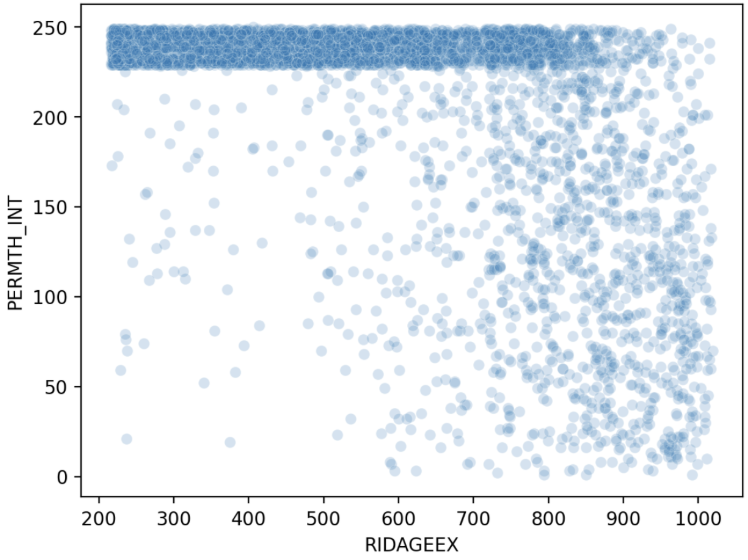

Based on the scatterplot above, there seems to be no correlation between PERMTH_INT and RIDAGEEX as there is no clear positive or negative trend. The data points seem to be pretty random with no correlational pattern. The R squared value is likely close to 0. The horizontal band at around 230-250 months represents a cap for the values and is likely why there is a cap. This ceiling is called a ceiling effect. The ceiling could be distorting the correlational value. This means a possible place we could go is cleaning these ‘ceiling’ values out. Overall, there is an extremely weak concentration that is likely very very close to 0.


4. Do pairs of categorical variables exhibit interesting patterns in contingency tables? -Lydia

Based on contingency tables, there is a clear inverse relationship between education level and mortality among the deceased group. When MORTSTAT is 1.0, Lower Education (Code 1) exhibits the highest mortality rate at approximately 46%, and Higher Education (Code 5) exhibits the lowest mortality rate at approximately 19%. However, as the education level increases, the probability of survival increases significantly. Education Code 1 has only 54% in the “alive” category, but Education Code 5 has 81% in the “alive” category. 
For income data among the deceased group, the lowest income (Code 1.0) shows a significantly higher mortality rate at about 21%, and the highest income shows a lower mortality rate at about 16%. While there is some fluctuation in the middle-income brackets, the overall trend shows that individuals in higher income categories generally have higher survival rates compared to those in the lowest brackets. When MORTSTAT is 0, there is a 79% survival, but this looks like an outlier based on the rest of the data and the general pattern. Income Code 2.0 has a survival rate of 51%, while Income Code 9.0 has a survival rate is 88%. Generally, there is a clear upward trend where higher income codes consistently show survival rates between 78% and 88% and lower brackets have a rate closer to 51%. 


5. Provide a clear discussion and examination of the data and the variables we are interested in using. -Pavi

The data we are looking at comes from the National Health and Nutrition Examination Survey. Each observation in this dataset represents an individual person. The main purpose of the data is to help us analyze and predict mortality and life expectancy for others based on this dataset. 

The variables discussed are ELIGSTAT, MORTSTAT, PERMTH_INT, and RIDAGEEX. ELIGSTAT is important because it tells us each person’s eligibility status for mortality linkage to the National Death Index. People are labeled as eligible, under age 18, or ineligible. MORTSTAT tells us whether the person is assumed to be alive or dead. PERMTH_INT gives us the amount of months that it has been since that person’s health has been followed up on. RIDAGEEX tells us the person’s age in months when they came in for their examination. These are the main variables we focused on, but some other ones we are interested in are Education Level and Income Data. 


# Day 2

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts) -Kaitlin

In this dataset, an observation is an individual person. There is a lot of missing data for certain variables such as MORSTAT and PERMTH_INT. This could impact analysis because it could create bias in our estimates for these variables. The data comes from the National Health and Nutrition Examination Survey, which is conducted bi-annually for the purpose of looking at trends in health and behavior. One limitation could be measurement error for self-reported data if people misreport their behaviors. Another limitation is that mortality can be wrongly linked to certain data, causing our prediction model to be less accurate. 


2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts) -Pavi

The variables we selected to predict mortality and life expectancy are mortality status and age in months. We thought age in months would be best to predict life expectancy because the higher their number is, the lower their life expectancy is likely to be. Additionally, we totaled the number of people assumed dead and assumed alive, which will help us predict mortality. 


3. Using your variables to predict mortality using a -Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select .(10/100 pts) -Isabelle

Mortality was predicted by looking at a person’s age (in months) and follow-up time. The kNN Classifier model had an accuracy of around 85%. Looking at the confusion matrix, we can also see how the model predicted 36 false positives and 60 false negatives (out of the 183 patients that were deceased). I selected the k value used by performing code that found the optimal k value. As a result, I discovered that the optimal k value is 89. 


4. Using your variables to predict life expectancy using a k-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select k. (10/100 pts) -Kaitlin

Life expectancy was predicted by looking at a person’s age (in months). The regression model achieved a R^2 value of 0.44, which is very moderate. This shows that although age captures general survival patterns,  there is a lot of variability in life expectancy that remains unexplained. This makes sense, given that there are many factors that contribute to life expectancy. The model performs decently well in the middle range (100-200 months), where there is the most data. However, it does not perform well for extreme data, such as people who died less than 50 months after the previous examination. The optimal k value was chosen by using code that plots the train and test R^2 for many values of k. The optimal k ended up being 145, which is quite large to account for the large sample size. 


5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts) -David

Firstly, when predicting mortality using a kNN classifier, patients with a high probability of mortality can be immediately prioritized with screenings and tests because the model has a high accuracy rate at 85%. In addition, when predicting life expectancy using a kNN regressor, healthcare workers are able to set realistic timetables and long-term goals for "middle range" (100-200 months) patients because the model's R squared value is only 44%. Also, since the data shows an inverse relationship between education level and income with mortality, health workers can focus on lower-income and lower-education brackets where survival rate is at its lowest. However, some limits or risks we should consider is that there is a high volume of missing data for both MORTSTAT and PERMTH_INT (risk of non-response bias), and that the NHANES data relies on self-reported behaviors which may include measurement errors. In addition, the 60 false negatives out of 183 deceased patients in the kNN classifer show that the model failed to identify almost 33% of patients who actually died but could have had life-saving opportunities. Furthermore, the R squared value being 0.44 shows that 56% of the variability is unexplained meaning relying on just age means leaving out vital information like genetics and lifestyle behaviors.


All codes for our responses are save seperately into the GitHub from each group member that wrote it. Day 1's work was a very collaborative effort, and the rest of the questions were split evenly between the group members. The question(s) that each person answered is labeled and written in this notebook for cleanliness and ease of grading.